In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def plot_series(time, series, format="-", start=0, end=None, label=None):
    plt.plot(time[start:end], series[start:end], format, label=label)
    plt.xlabel("Time")
    plt.ylabel("Value")
    if label:
        plt.legend(fontsize=14)
    plt.grid(True)

In [3]:
def trend(time, slope=0):
    return slope * time

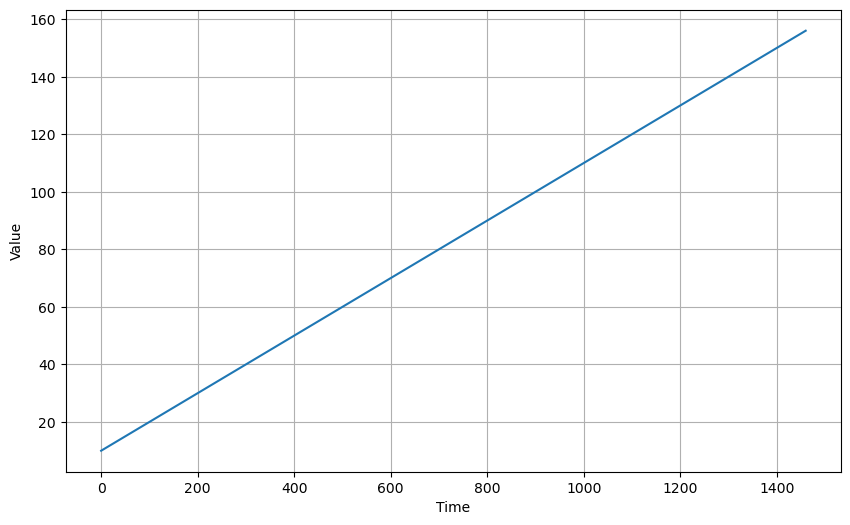

In [4]:
time = np.arange(4 * 365 + 1)
baseline = 10
series = baseline + trend(time, 0.1)

plt.figure(figsize=(10, 6))
plot_series(time, series)
plt.show()

In [5]:
time

array([   0,    1,    2, ..., 1458, 1459, 1460])

In [6]:
series

array([ 10. ,  10.1,  10.2, ..., 155.8, 155.9, 156. ])

In [7]:
def seasonal_pattern(season_time):
    """Just an arbitrary pattern, you can change it if you wish"""
    return np.where(season_time < 0.4,
                    np.cos(season_time * 2 * np.pi),
                    1 / np.exp(3 * season_time))

def seasonality(time, period, amplitude=1, phase=0):
    """Repeats the same pattern at each period"""
    season_time = ((time + phase) % period) / period
    return amplitude * seasonal_pattern(season_time)

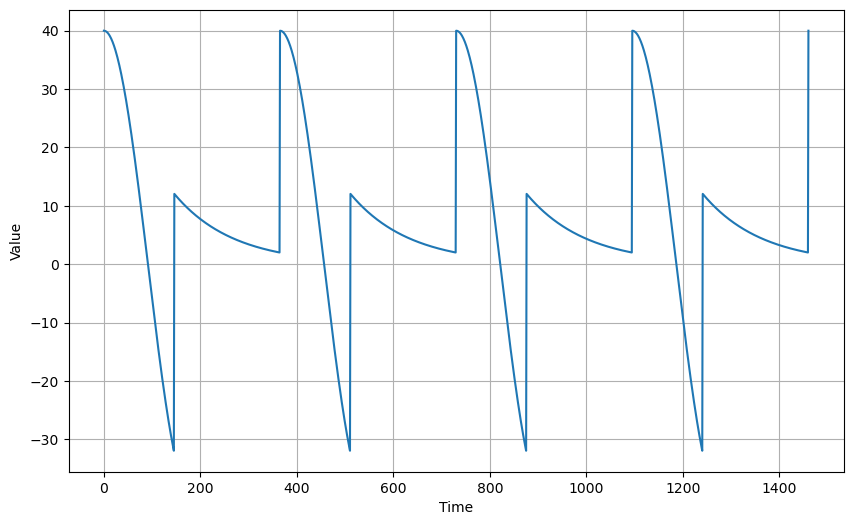

In [8]:
amplitude = 40
series = seasonality(time, period=365, amplitude=amplitude)

plt.figure(figsize=(10, 6))
plot_series(time, series)
plt.show()

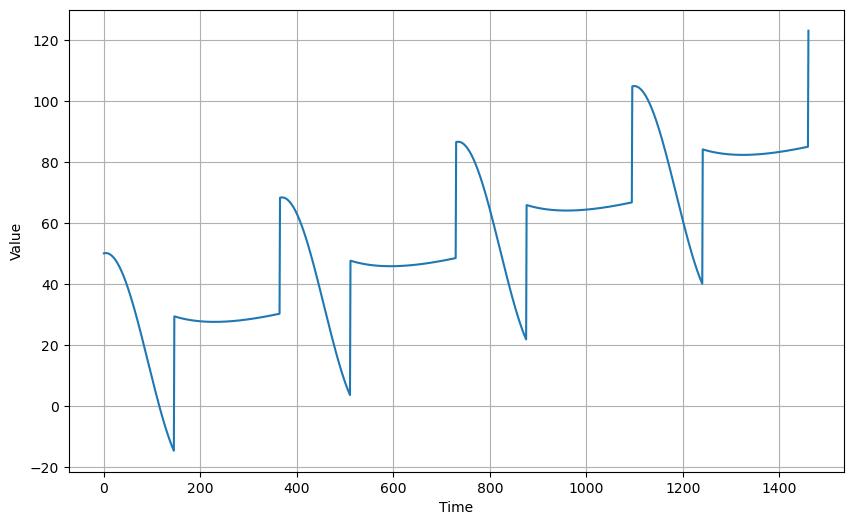

In [9]:
slope = 0.05
series = baseline + trend(time, slope) + seasonality(time, period=365, amplitude=amplitude)

plt.figure(figsize=(10, 6))
plot_series(time, series)
plt.show()

In [10]:
def white_noise(time, noise_level=1, seed=None):
    rnd = np.random.RandomState(seed)
    return rnd.randn(len(time)) * noise_level

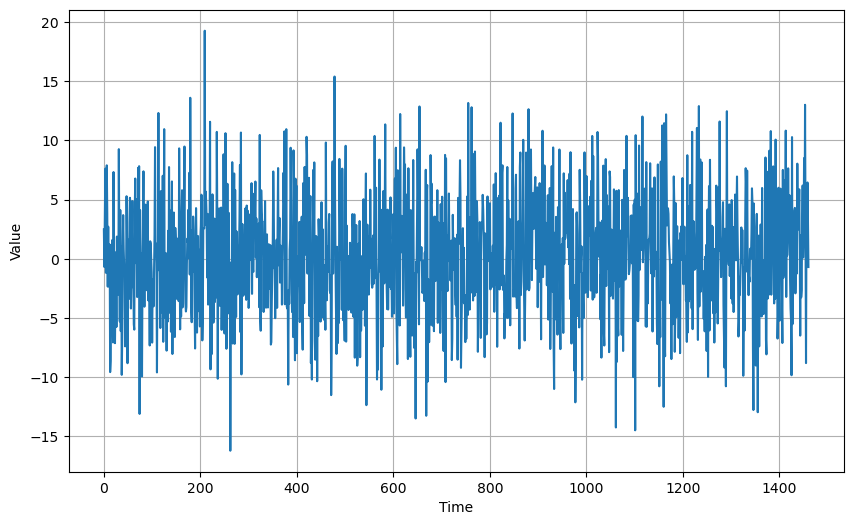

In [11]:
noise_level = 5
noise = white_noise(time, noise_level, seed=42)

plt.figure(figsize=(10, 6))
plot_series(time, noise)
plt.show()

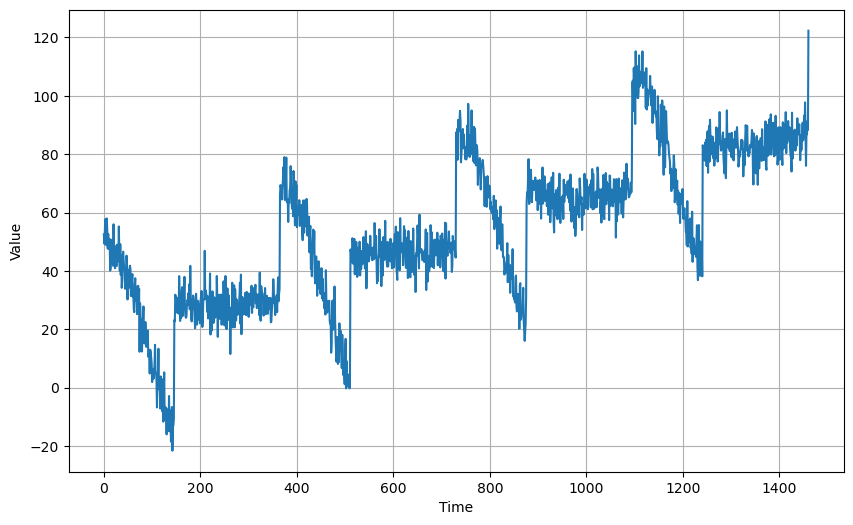

In [12]:
series += noise

plt.figure(figsize=(10, 6))
plot_series(time, series)
plt.show()

## Naive Forecasting

In [13]:
import numpy as np
import matplotlib.pyplot as plt

In [14]:
def plot_series(time, series, format="-", start=0, end=None, label=None):
    plt.plot(time[start:end], series[start:end], format, label=label)
    plt.xlabel("Time")
    plt.ylabel("Value")
    if label:
        plt.legend(fontsize=14)
    plt.grid(True)
    
def trend(time, slope=0):
    return slope * time

def seasonal_pattern(season_time):
    """Just an arbitrary pattern, you can change it if you wish"""
    return np.where(season_time < 0.4,
                    np.cos(season_time * 2 * np.pi),
                    1 / np.exp(3 * season_time))
  
def seasonality(time, period, amplitude=1, phase=0):
    """Repeats the same pattern at each period"""
    season_time = ((time + phase) % period) / period
    return amplitude * seasonal_pattern(season_time)
    
def white_noise(time, noise_level=1, seed=None):
    rnd = np.random.RandomState(seed)
    return rnd.randn(len(time)) * noise_level

## Trend and Seasonality

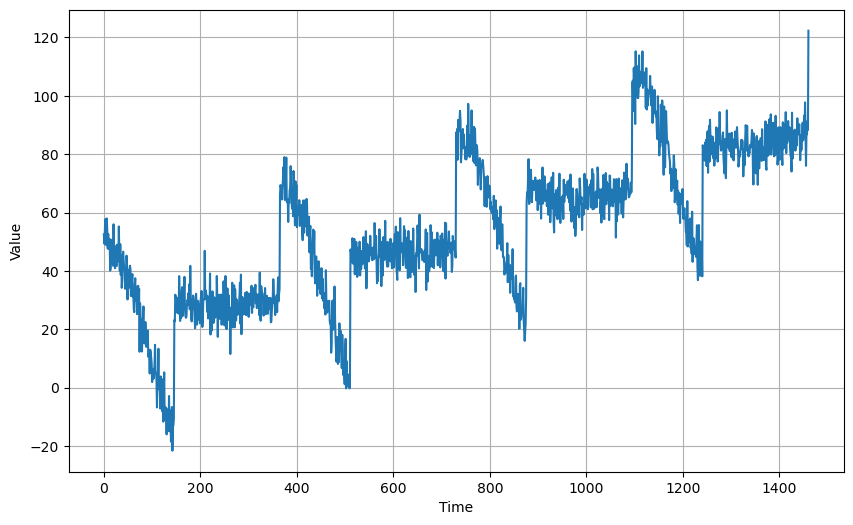

In [15]:
time = np.arange(4 * 365 + 1)

slope = 0.05
baseline = 10
amplitude = 40
series = baseline + trend(time, slope) + seasonality(time, period=365, amplitude=amplitude)

noise_level = 5
noise = white_noise(time, noise_level, seed=42)

series += noise

plt.figure(figsize=(10, 6))
plot_series(time, series)
plt.show()

In [16]:
split_time = 1000
time_train = time[:split_time]
x_train = series[:split_time]
time_valid = time[split_time:]
x_valid = series[split_time:]

## Naive Forecast

In [17]:
naive_forecast = series[split_time - 1:-1]

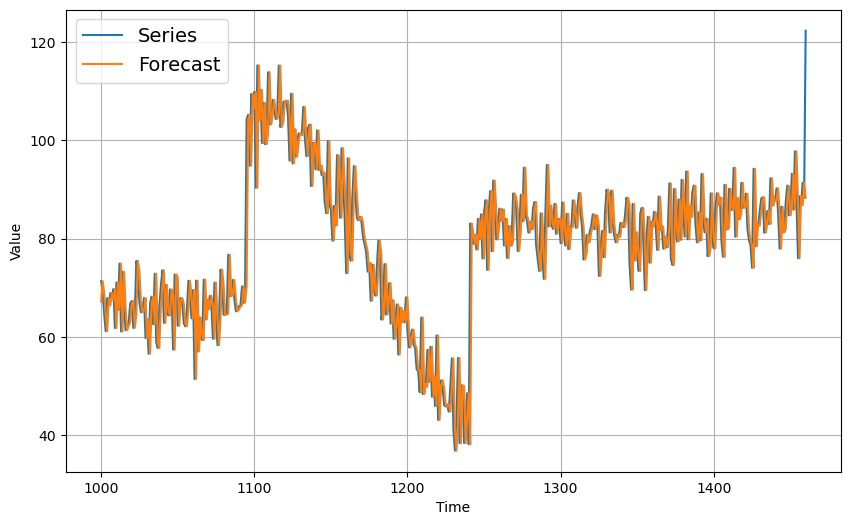

In [19]:
plt.figure(figsize=(10, 6))
plot_series(time_valid, x_valid, label="Series")
plot_series(time_valid, naive_forecast, label="Forecast")

In [29]:
series[0:-1]

array([52.48357077, 49.35275206, 53.31473872, ..., 86.79699012,
       91.37325376, 88.32382529])

In [27]:
series

array([ 52.48357077,  49.35275206,  53.31473872, ...,  91.37325376,
        88.32382529, 122.30772008])

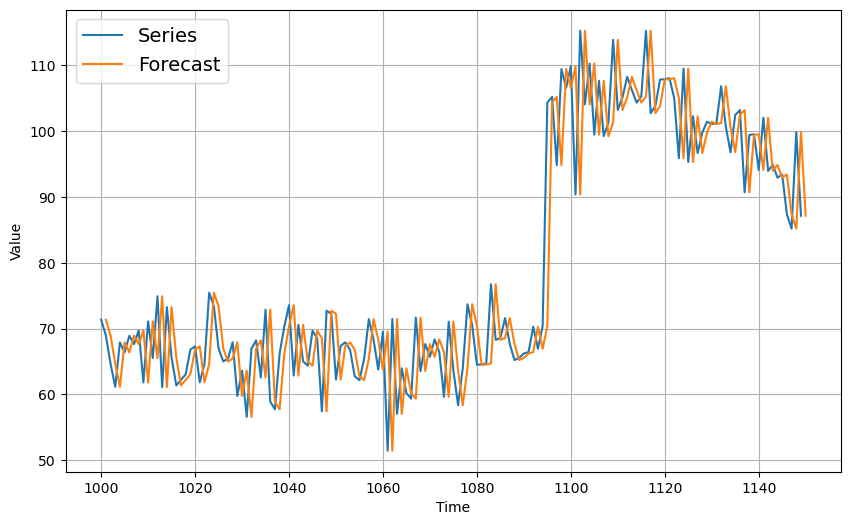

In [30]:
plt.figure(figsize=(10, 6))
plot_series(time_valid, x_valid, start=0, end=150, label="Series")
plot_series(time_valid, naive_forecast, start=1, end=151, label="Forecast")

In [31]:
errors = naive_forecast - x_valid
abs_errors = np.abs(errors)
mae = abs_errors.mean()
mae

5.9379085153216735

## Moving Average

In [32]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

keras = tf.keras

In [33]:
def plot_series(time, series, format="-", start=0, end=None, label=None):
    plt.plot(time[start:end], series[start:end], format, label=label)
    plt.xlabel("Time")
    plt.ylabel("Value")
    if label:
        plt.legend(fontsize=14)
    plt.grid(True)
    
def trend(time, slope=0):
    return slope * time

def seasonal_pattern(season_time):
    """Just an arbitrary pattern, you can change it if you wish"""
    return np.where(season_time < 0.4,
                    np.cos(season_time * 2 * np.pi),
                    1 / np.exp(3 * season_time))

def seasonality(time, period, amplitude=1, phase=0):
    """Repeats the same pattern at each period"""
    season_time = ((time + phase) % period) / period
    return amplitude * seasonal_pattern(season_time)

def white_noise(time, noise_level=1, seed=None):
    rnd = np.random.RandomState(seed)
    return rnd.randn(len(time)) * noise_level

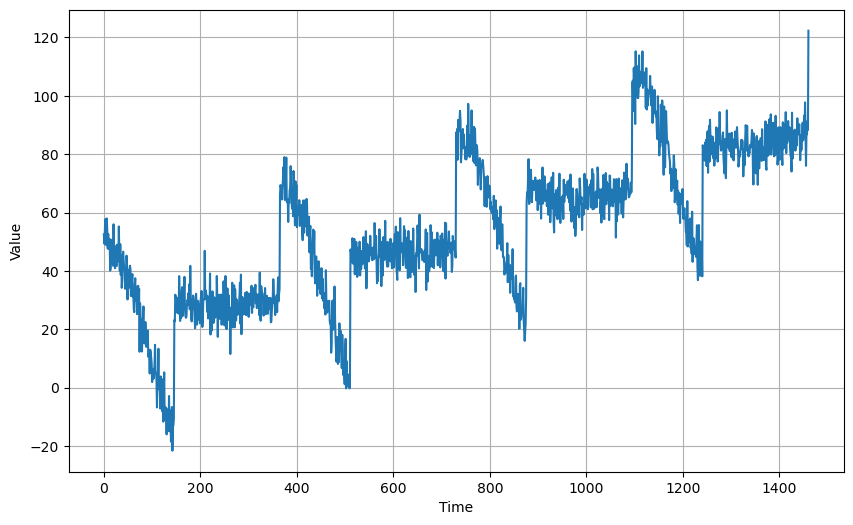

In [34]:
time = np.arange(4 * 365 + 1)

slope = 0.05
baseline = 10
amplitude = 40
series = baseline + trend(time, slope) + seasonality(time, period=365, amplitude=amplitude)

noise_level = 5
noise = white_noise(time, noise_level, seed=42)

series += noise

plt.figure(figsize=(10, 6))
plot_series(time, series)
plt.show()

## Naive Forecast

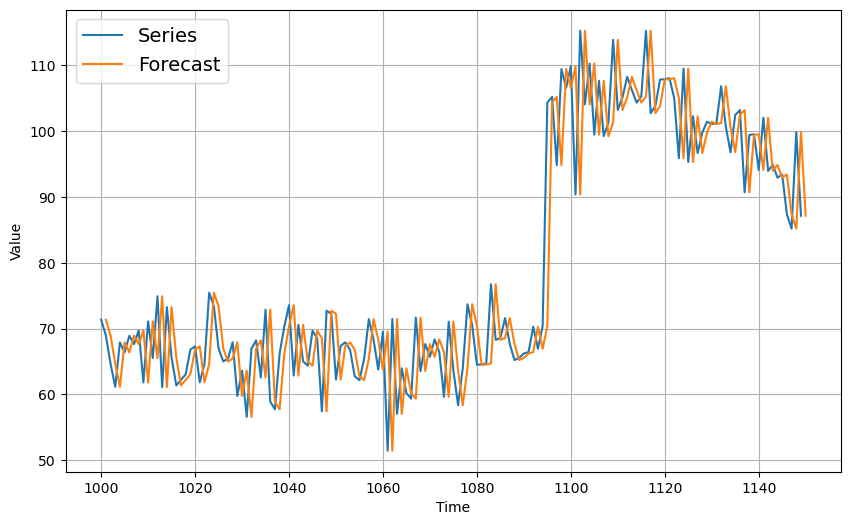

In [35]:
split_time = 1000
time_train = time[:split_time]
x_train = series[:split_time]
time_valid = time[split_time:]
x_valid = series[split_time:]

naive_forecast = series[split_time - 1:-1]

plt.figure(figsize=(10, 6))
plot_series(time_valid, x_valid, start=0, end=150, label="Series")
plot_series(time_valid, naive_forecast, start=1, end=151, label="Forecast")

In [37]:
import keras
keras.metrics.mean_absolute_error(x_valid, naive_forecast).numpy()

5.9379085153216735

## Moving Average

In [38]:
def moving_average_forecast(series, window_size):
  """Forecasts the mean of the last few values.
     If window_size=1, then this is equivalent to naive forecast"""
  forecast = []
  for time in range(len(series) - window_size):
    forecast.append(series[time:time + window_size].mean())
  return np.array(forecast)

In [39]:
def moving_average_forecast(series, window_size):
  """Forecasts the mean of the last few values.
     If window_size=1, then this is equivalent to naive forecast
     This implementation is *much* faster than the previous one"""
  mov = np.cumsum(series)
  mov[window_size:] = mov[window_size:] - mov[:-window_size]
  return mov[window_size - 1:-1] / window_size

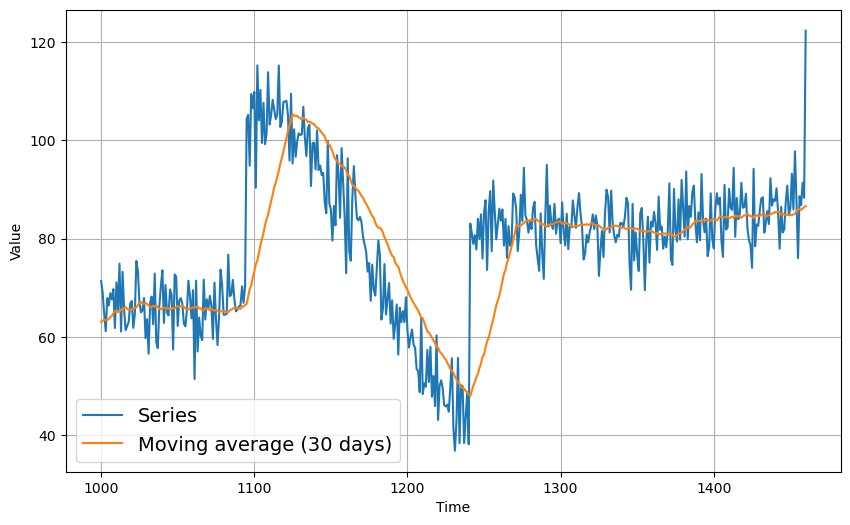

In [40]:
moving_avg = moving_average_forecast(series, 30)[split_time - 30:]

plt.figure(figsize=(10, 6))
plot_series(time_valid, x_valid, label="Series")
plot_series(time_valid, moving_avg, label="Moving average (30 days)")

In [41]:
keras.metrics.mean_absolute_error(x_valid, moving_avg).numpy()

7.142418570620786

### That's worse than naive forecast! The moving average does not anticipate trend or seasonality, so let's try to remove them by using differencing. Since the seasonality period is 365 days, we will subtract the value at time t – 365 from the value at time t.

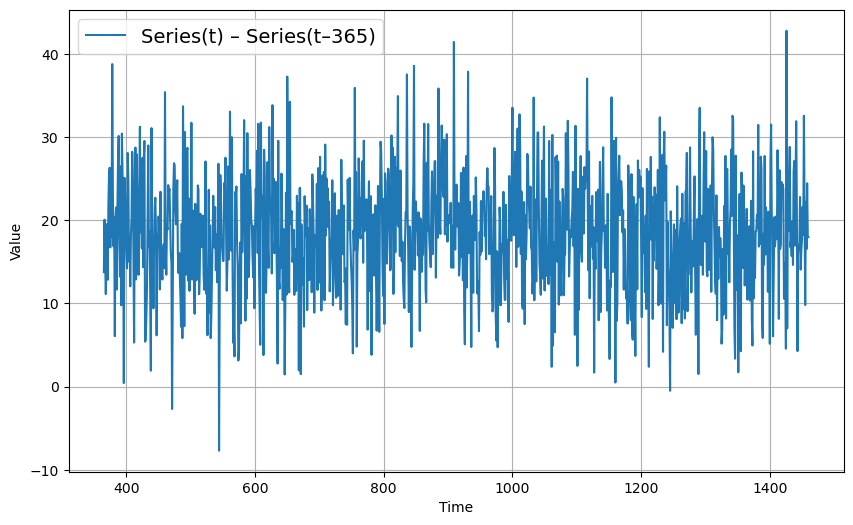

In [42]:
diff_series = (series[365:] - series[:-365])
diff_time = time[365:]

plt.figure(figsize=(10, 6))
plot_series(diff_time, diff_series, label="Series(t) – Series(t–365)")
plt.show()

### en el tiempo de validación

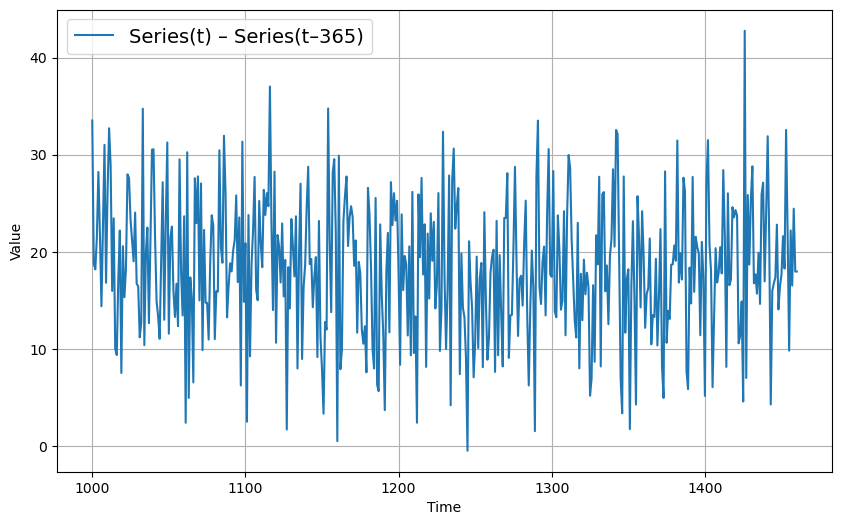

In [43]:
plt.figure(figsize=(10, 6))
plot_series(time_valid, diff_series[split_time - 365:], label="Series(t) – Series(t–365)")
plt.show()

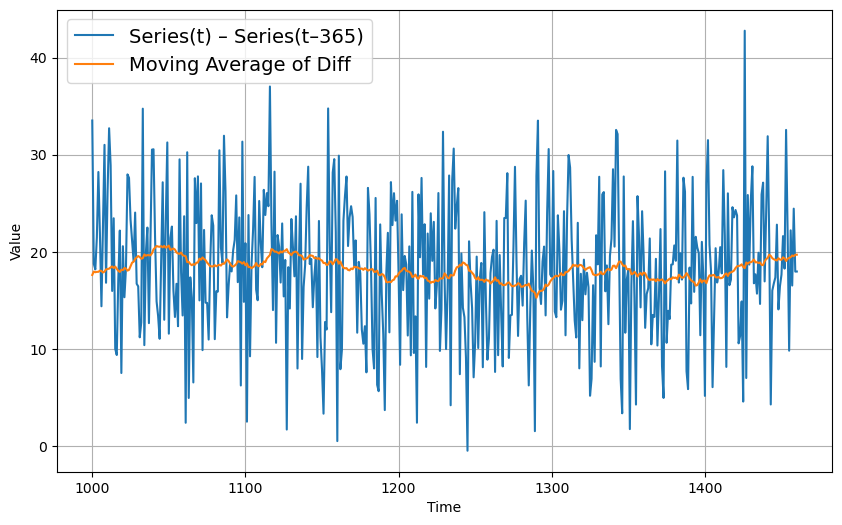

In [44]:
diff_moving_avg = moving_average_forecast(diff_series, 50)[split_time - 365 - 50:]

plt.figure(figsize=(10, 6))
plot_series(time_valid, diff_series[split_time - 365:], label="Series(t) – Series(t–365)")
plot_series(time_valid, diff_moving_avg, label="Moving Average of Diff")
plt.show()

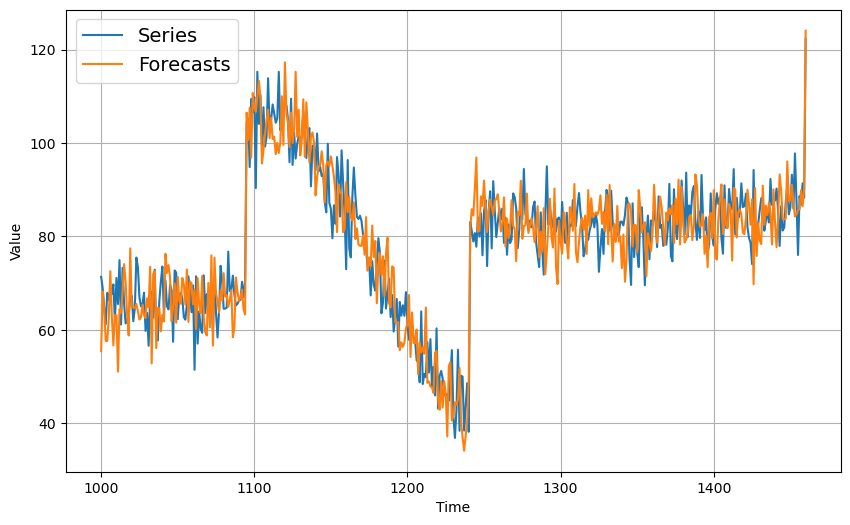

In [45]:
diff_moving_avg_plus_past = series[split_time - 365:-365] + diff_moving_avg

plt.figure(figsize=(10, 6))
plot_series(time_valid, x_valid, label="Series")
plot_series(time_valid, diff_moving_avg_plus_past, label="Forecasts")
plt.show()

In [46]:
keras.metrics.mean_absolute_error(x_valid, diff_moving_avg_plus_past).numpy()

5.8393105629958955

### Better than naive forecast, good. However the forecasts look a bit too random, because we're just adding past values, which were noisy. Let's use a moving averaging on past values to remove some of the noise:

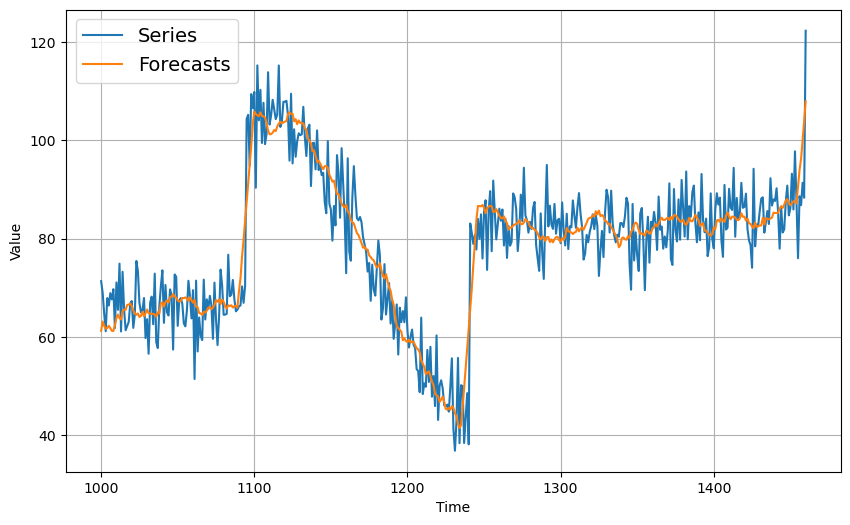

In [47]:
diff_moving_avg_plus_smooth_past = moving_average_forecast(series[split_time - 370:-359], 11) + diff_moving_avg

plt.figure(figsize=(10, 6))
plot_series(time_valid, x_valid, label="Series")
plot_series(time_valid, diff_moving_avg_plus_smooth_past, label="Forecasts")
plt.show()

In [48]:
keras.metrics.mean_absolute_error(x_valid, diff_moving_avg_plus_smooth_past).numpy()

4.566859958970771

## Windows hacia adelante

In [50]:
dataset = tf.data.Dataset.range(10)
dataset

<_RangeDataset element_spec=TensorSpec(shape=(), dtype=tf.int64, name=None)>

In [51]:
dataset = dataset.window(5, shift=1)
dataset

<_WindowDataset element_spec=DatasetSpec(TensorSpec(shape=(), dtype=tf.int64, name=None), TensorShape([]))>

In [53]:
for window_dataset in dataset:
    for val in window_dataset:
        print(val.numpy(), end=" ")
    print()

0 1 2 3 4 
1 2 3 4 5 
2 3 4 5 6 
3 4 5 6 7 
4 5 6 7 8 
5 6 7 8 9 
6 7 8 9 
7 8 9 
8 9 
9 


In [54]:
dataset = tf.data.Dataset.range(10)
dataset = dataset.window(5, shift=1, drop_remainder= True)
for window_dataset in dataset:
    for val in window_dataset:
        print(val.numpy(), end=" ")
    print()

0 1 2 3 4 
1 2 3 4 5 
2 3 4 5 6 
3 4 5 6 7 
4 5 6 7 8 
5 6 7 8 9 


## TensorFlow requiere tensores

In [58]:
dataset = tf.data.Dataset.range(10)
dataset = dataset.window(5, shift=1, drop_remainder= True)
dataset = dataset.flat_map(lambda window: window.batch(5))
for window in dataset:
    print(window.numpy())

[0 1 2 3 4]
[1 2 3 4 5]
[2 3 4 5 6]
[3 4 5 6 7]
[4 5 6 7 8]
[5 6 7 8 9]


## TensorFlow requiere entradas (4) y una salida

In [59]:
dataset = tf.data.Dataset.range(10)
dataset = dataset.window(5, shift=1, drop_remainder= True)
dataset = dataset.flat_map(lambda window: window.batch(5))
dataset = dataset.map(lambda window: (window[:-1], window[-1:]))
for x,y in dataset:
    print(x.numpy() , y.numpy())

[0 1 2 3] [4]
[1 2 3 4] [5]
[2 3 4 5] [6]
[3 4 5 6] [7]
[4 5 6 7] [8]
[5 6 7 8] [9]


## TensorFlow requiere entradas barajadas

In [64]:
dataset = tf.data.Dataset.range(10)
dataset = dataset.window(5, shift=1, drop_remainder= True)
dataset = dataset.flat_map(lambda window: window.batch(5))
dataset = dataset.map(lambda window: (window[:-1], window[-1:]))
dataset = dataset.shuffle(buffer_size=10)
for x,y in dataset:
    print(x.numpy() , y.numpy())

[5 6 7 8] [9]
[2 3 4 5] [6]
[3 4 5 6] [7]
[0 1 2 3] [4]
[1 2 3 4] [5]
[4 5 6 7] [8]


## TensorFlow requiere entradas barajadas independientes de entradas y salidas

In [65]:
dataset = tf.data.Dataset.range(10)
dataset = dataset.window(5, shift=1, drop_remainder= True)
dataset = dataset.flat_map(lambda window: window.batch(5))
dataset = dataset.map(lambda window: (window[:-1], window[-1:]))
dataset = dataset.shuffle(buffer_size=10)
for x,y in dataset:
    print("x = ", x.numpy())
    print("y = ", y.numpy())

x =  [3 4 5 6]
y =  [7]
x =  [0 1 2 3]
y =  [4]
x =  [5 6 7 8]
y =  [9]
x =  [1 2 3 4]
y =  [5]
x =  [4 5 6 7]
y =  [8]
x =  [2 3 4 5]
y =  [6]


In [66]:
dataset = tf.data.Dataset.range(10)
dataset = dataset.window(5, shift=1, drop_remainder= True)
dataset = dataset.flat_map(lambda window: window.batch(5))
dataset = dataset.map(lambda window: (window[:-1], window[-1:]))
dataset = dataset.shuffle(buffer_size=10)
dataset = dataset.batch(2).prefetch(1)
for x,y in dataset:
    print("x = ", x.numpy())
    print("y = ", y.numpy())

x =  [[1 2 3 4]
 [5 6 7 8]]
y =  [[5]
 [9]]
x =  [[0 1 2 3]
 [4 5 6 7]]
y =  [[4]
 [8]]
x =  [[2 3 4 5]
 [3 4 5 6]]
y =  [[6]
 [7]]


In [70]:
def window_dataset(series, window_size, batch_size=32):
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size + 1 , shift=1, drop_remainder= True)
    ds = ds.flat_map(lambda window: window.batch(window_size + 1))
    ds = ds.map(lambda window: (window[:-1], window[-1:]))
    ds = ds.shuffle(len(series))
    return ds.batch(batch_size).prefetch(1)
    

## Pronósticos con Machine Learning

In [71]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

import keras

In [72]:
def plot_series(time, series, format="-", start=0, end=None, label=None):
    plt.plot(time[start:end], series[start:end], format, label=label)
    plt.xlabel("Time")
    plt.ylabel("Value")
    if label:
        plt.legend(fontsize=14)
    plt.grid(True)
    
def trend(time, slope=0):
    return slope * time
  
  
def seasonal_pattern(season_time):
    """Just an arbitrary pattern, you can change it if you wish"""
    return np.where(season_time < 0.4,
                    np.cos(season_time * 2 * np.pi),
                    1 / np.exp(3 * season_time))

  
def seasonality(time, period, amplitude=1, phase=0):
    """Repeats the same pattern at each period"""
    season_time = ((time + phase) % period) / period
    return amplitude * seasonal_pattern(season_time)
  
  
def white_noise(time, noise_level=1, seed=None):
    rnd = np.random.RandomState(seed)
    return rnd.randn(len(time)) * noise_level

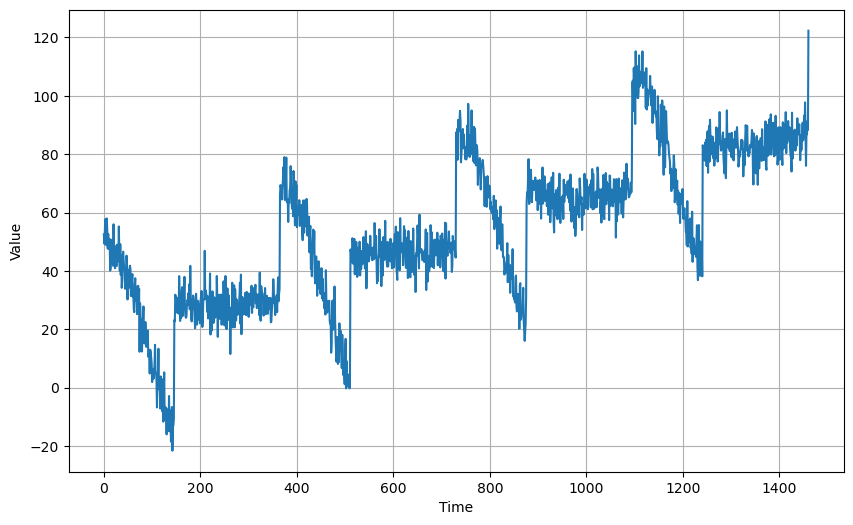

In [73]:
time = np.arange(4 * 365 + 1)

slope = 0.05
baseline = 10
amplitude = 40
series = baseline + trend(time, slope) + seasonality(time, period=365, amplitude=amplitude)

noise_level = 5
noise = white_noise(time, noise_level, seed=42)

series += noise

plt.figure(figsize=(10, 6))
plot_series(time, series)
plt.show()

## Forecasting with Machine Learning

### First, we will train a model to forecast the next step given the previous 30 steps, therefore, we need to create a dataset of 30-step windows for training.

In [74]:
def window_dataset(series, window_size, batch_size=32,
                   shuffle_buffer=1000):
    dataset = tf.data.Dataset.from_tensor_slices(series)
    dataset = dataset.window(window_size + 1, shift=1, drop_remainder=True)
    dataset = dataset.flat_map(lambda window: window.batch(window_size + 1))
    dataset = dataset.shuffle(shuffle_buffer)
    dataset = dataset.map(lambda window: (window[:-1], window[-1]))
    dataset = dataset.batch(batch_size).prefetch(1)
    return dataset

In [75]:
split_time = 1000
time_train = time[:split_time]
x_train = series[:split_time]
time_valid = time[split_time:]
x_valid = series[split_time:]

## Linear Model

In [77]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

window_size = 30
train_set = window_dataset(x_train, window_size)
valid_set = window_dataset(x_valid, window_size)

model = keras.models.Sequential([
  keras.layers.Dense(1, input_shape=[window_size])
])
optimizer = keras.optimizers.SGD(learning_rate=1e-5, momentum=0.9)
model.compile(loss=keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])
model.fit(train_set, epochs=100, validation_data=valid_set)

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 37.5249 - mae: 38.0225 - val_loss: 13.8078 - val_mae: 14.2991
Epoch 2/100


C:\Users\ftorr\anaconda3\envs\NuevoAmbiente\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 12.0621 - mae: 12.5535 - val_loss: 11.3737 - val_mae: 11.8637
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11.5286 - mae: 12.0166 - val_loss: 10.6414 - val_mae: 11.1250
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 11.2794 - mae: 11.7678 - val_loss: 10.3263 - val_mae: 10.8142
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.1553 - mae: 10.6436 - val_loss: 10.3615 - val_mae: 10.8546
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.0087 - mae: 10.4959 - val_loss: 9.8211 - val_mae: 10.3059
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.9665 - mae: 10.4539 - val_loss: 9.6383 - val_mae: 10.1230
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 10.2036 - mae: 10.6942 - val_loss: 9.5602 - val_mae: 10.0431
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.4950 - mae: 9.9814 - val_loss: 10.1337 - val_mae: 10.6235
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/ste

In [78]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

window_size = 30
train_set = window_dataset(x_train, window_size)

model = keras.models.Sequential([
  keras.layers.Dense(1, input_shape=[window_size])
])

lr_schedule = keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-6 * 10**(epoch / 30))
optimizer = keras.optimizers.SGD(learning_rate=1e-6, momentum=0.9)
model.compile(loss=keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])
history = model.fit(train_set, epochs=100, callbacks=[lr_schedule])

Epoch 1/100


C:\Users\ftorr\anaconda3\envs\NuevoAmbiente\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 75.6763 - mae: 76.1759 - learning_rate: 1.0000e-06
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 866us/step - loss: 60.2685 - mae: 60.7677 - learning_rate: 1.0798e-06
Epoch 3/100
 2/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 45.3980 - mae: 45.1864

C:\Users\ftorr\anaconda3\envs\NuevoAmbiente\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 42.7355 - mae: 43.2335 - learning_rate: 1.1659e-06
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 974us/step - loss: 24.0415 - mae: 24.5404 - learning_rate: 1.2589e-06
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 817us/step - loss: 9.3950 - mae: 9.8827 - learning_rate: 1.3594e-06
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 861us/step - loss: 7.8891 - mae: 8.3807 - learning_rate: 1.4678e-06
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 903us/step - loss: 8.2147 - mae: 8.7012 - learning_rate: 1.5849e-06
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 942us/step - loss: 8.0188 - mae: 8.5019 - learning_rate: 1.7113e-06
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 915us/step - loss: 7.7033 - mae: 8.1872 - learning_rate: 1.8478e-06
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 842us/step - loss: 7.7537 - mae: 8.2362 - learning_rate: 1.9953e-06
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 892us/step - loss: 8.2284 - mae: 8.7117 - learning_rate: 2.1544e-06
Epoch 12/100
31/31

(1e-06, 0.001, 0.0, 20.0)

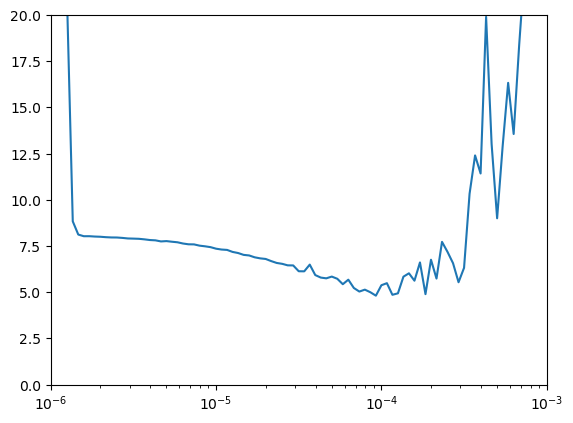

In [80]:
plt.semilogx(history.history["learning_rate"], history.history["loss"])
plt.axis([1e-6, 1e-3, 0, 20])

In [81]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

window_size = 30
train_set = window_dataset(x_train, window_size)
valid_set = window_dataset(x_valid, window_size)

model = keras.models.Sequential([
  keras.layers.Dense(1, input_shape=[window_size])
])
optimizer = keras.optimizers.SGD(learning_rate=1e-5, momentum=0.9)
model.compile(loss=keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])
early_stopping = keras.callbacks.EarlyStopping(patience=10)
model.fit(train_set, epochs=500,
          validation_data=valid_set,
          callbacks=[early_stopping])

Epoch 1/500


C:\Users\ftorr\anaconda3\envs\NuevoAmbiente\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 76.8800 - mae: 77.3776 - val_loss: 23.1487 - val_mae: 23.6476
Epoch 2/500


C:\Users\ftorr\anaconda3\envs\NuevoAmbiente\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 14.1556 - mae: 14.6487 - val_loss: 8.7681 - val_mae: 9.2576
Epoch 3/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.7206 - mae: 10.2057 - val_loss: 8.2196 - val_mae: 8.6997
Epoch 4/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.7582 - mae: 9.2450 - val_loss: 7.9123 - val_mae: 8.3951
Epoch 5/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.6877 - mae: 8.1700 - val_loss: 7.4932 - val_mae: 7.9794
Epoch 6/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.7517 - mae: 8.2380 - val_loss: 7.4088 - val_mae: 7.8936
Epoch 7/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.3458 - mae: 7.8272 - val_loss: 6.9229 - val_mae: 7.4053
Epoch 8/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1292 - mae: 7.6100 - val_loss: 6.7769 - val_mae: 7.2635
Epoch 9/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0858 - mae: 7.5662 - val_loss: 6.7876 - val_mae: 7.2756
Epoch 10/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6344 - mae:

In [82]:
def model_forecast(model, series, window_size):
    ds = tf.data.Dataset.from_tensor_slices(series)
    ds = ds.window(window_size, shift=1, drop_remainder=True)
    ds = ds.flat_map(lambda w: w.batch(window_size))
    ds = ds.batch(32).prefetch(1)
    forecast = model.predict(ds)
    return forecast

In [83]:
lin_forecast = model_forecast(model, series[split_time - window_size:-1], window_size)[:, 0]

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


In [84]:
lin_forecast.shape

(461,)

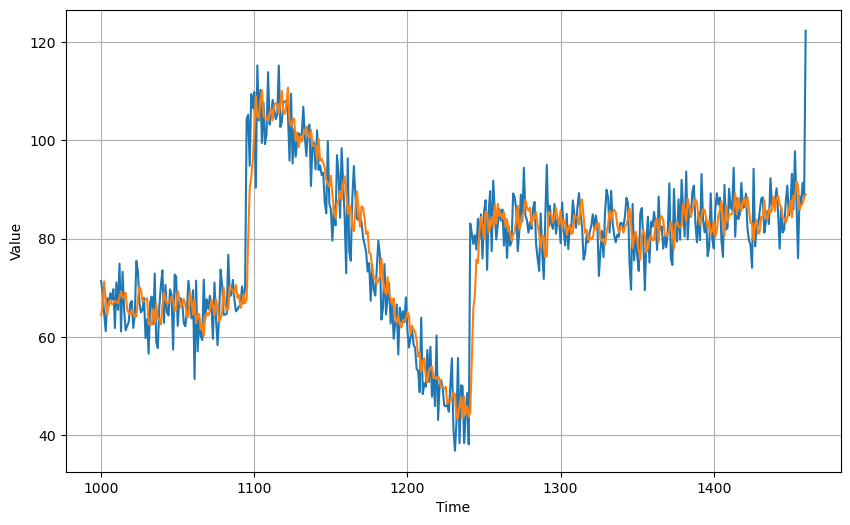

In [85]:
plt.figure(figsize=(10, 6))
plot_series(time_valid, x_valid)
plot_series(time_valid, lin_forecast)

In [86]:
keras.metrics.mean_absolute_error(x_valid, lin_forecast).numpy()

4.9223633

In [87]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

window_size = 30
train_set = window_dataset(x_train, window_size)

model = keras.models.Sequential([
  keras.layers.Dense(10, activation="relu", input_shape=[window_size]),
  keras.layers.Dense(10, activation="relu"),
  keras.layers.Dense(1)
])

lr_schedule = keras.callbacks.LearningRateScheduler(
    lambda epoch: 1e-7 * 10**(epoch / 20))
optimizer = keras.optimizers.SGD(learning_rate=1e-7, momentum=0.9)
model.compile(loss=keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])
history = model.fit(train_set, epochs=100, callbacks=[lr_schedule])

Epoch 1/100


C:\Users\ftorr\anaconda3\envs\NuevoAmbiente\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 24.0451 - mae: 24.5432 - learning_rate: 1.0000e-07
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 24.3131 - mae: 24.8094 - learning_rate: 1.1220e-07
Epoch 3/100


C:\Users\ftorr\anaconda3\envs\NuevoAmbiente\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 23.8614 - mae: 24.3590 - learning_rate: 1.2589e-07
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 23.1004 - mae: 23.5996 - learning_rate: 1.4125e-07
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 22.3688 - mae: 22.8679 - learning_rate: 1.5849e-07
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 22.7975 - mae: 23.2962 - learning_rate: 1.7783e-07
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 951us/step - loss: 21.7337 - mae: 22.2332 - learning_rate: 1.9953e-07
Epoch 8/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 21.5182 - mae: 22.0167 - learning_rate: 2.2387e-07
Epoch 9/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 905us/step - loss: 19.7645 - mae: 20.2608 - learning_rate: 2.5119e-07
Epoch 10/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 975us/step - loss: 19.4019 - mae: 19.8973 - learning_rate: 2.8184e-07
Epoch 11/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 959us/step - loss: 18.5840 - mae: 19.0790 - learning_rate: 3.1623e-07
Epoch 12/100

(1e-07, 0.005, 0.0, 30.0)

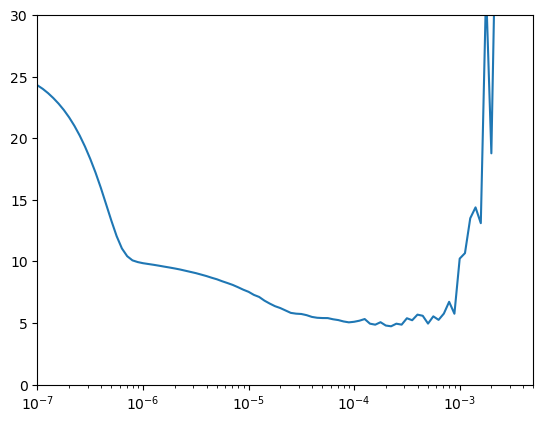

In [88]:
plt.semilogx(history.history["learning_rate"], history.history["loss"])
plt.axis([1e-7, 5e-3, 0, 30])

In [89]:
keras.backend.clear_session()
tf.random.set_seed(42)
np.random.seed(42)

window_size = 30
train_set = window_dataset(x_train, window_size)
valid_set = window_dataset(x_valid, window_size)

model = keras.models.Sequential([
  keras.layers.Dense(10, activation="relu", input_shape=[window_size]),
  keras.layers.Dense(10, activation="relu"),
  keras.layers.Dense(1)
])

optimizer = keras.optimizers.SGD(learning_rate=1e-5, momentum=0.9)
model.compile(loss=keras.losses.Huber(),
              optimizer=optimizer,
              metrics=["mae"])
early_stopping = keras.callbacks.EarlyStopping(patience=10)
model.fit(train_set, epochs=500,
          validation_data=valid_set,
          callbacks=[early_stopping])

Epoch 1/500


C:\Users\ftorr\anaconda3\envs\NuevoAmbiente\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 37.2589 - mae: 37.7580 - val_loss: 7.9326 - val_mae: 8.4189
Epoch 2/500


C:\Users\ftorr\anaconda3\envs\NuevoAmbiente\Lib\contextlib.py:158: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self.gen.throw(typ, value, traceback)


31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 9.2591 - mae: 9.7474 - val_loss: 8.4778 - val_mae: 8.9669
Epoch 3/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.2675 - mae: 8.7561 - val_loss: 7.0340 - val_mae: 7.5165
Epoch 4/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.9582 - mae: 8.4413 - val_loss: 6.3368 - val_mae: 6.8156
Epoch 5/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.0806 - mae: 7.5587 - val_loss: 6.2254 - val_mae: 6.7085
Epoch 6/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1508 - mae: 7.6303 - val_loss: 6.0759 - val_mae: 6.5554
Epoch 7/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 7.1891 - mae: 7.6745 - val_loss: 6.1250 - val_mae: 6.6090
Epoch 8/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.9894 - mae: 7.4682 - val_loss: 5.9414 - val_mae: 6.4226
Epoch 9/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.8026 - mae: 7.2825 - val_loss: 5.9579 - val_mae: 6.4390
Epoch 10/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 6.4707 - mae: 6.

In [90]:
dense_forecast = model_forecast(
    model,
    series[split_time - window_size:-1],
    window_size)[:, 0]

15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


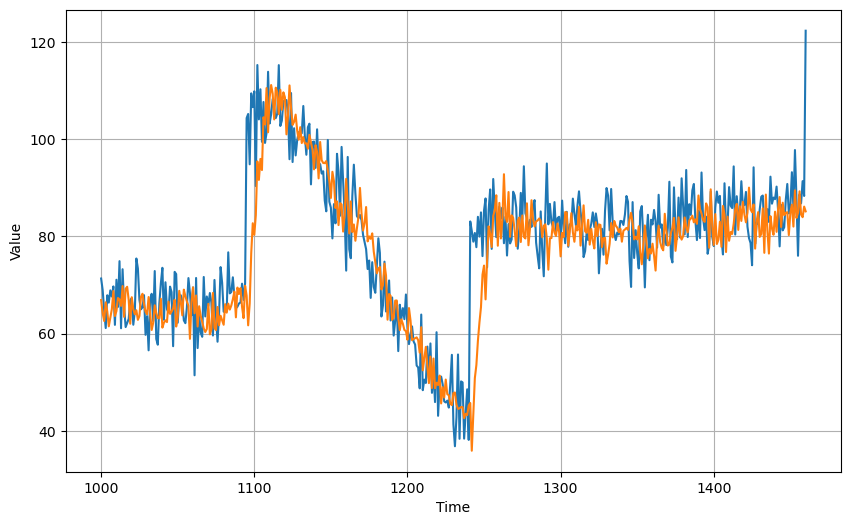

In [91]:
plt.figure(figsize=(10, 6))
plot_series(time_valid, x_valid)
plot_series(time_valid, dense_forecast)

In [92]:
keras.metrics.mean_absolute_error(x_valid, dense_forecast).numpy()

5.8182015